In [1]:
# 1. Important Libraries Import Karna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings hide karne ke liye (taaki output clean lage)
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# 2. Dataset Load Karna (Exact Absolute Path ke saath)

file_path = r'C:\Users\hp\Desktop\HR_Analytics_Portfolio_Project\1_Data\Raw_Data\HR_Data.csv'

df = pd.read_csv(file_path)

# 3. Data Cleaning
df = df.drop(['EmployeeCount', 'Over18', 'StandardHours'], axis=1)
df['Attrition'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

print("Data Cleaning Successful! Here is the preview:")
display(df.head())

Data Cleaning Successful! Here is the preview:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,31,0,Travel_Rarely,106,Human Resources,2,3,Human Resources,424,1,...,3,4,0,9,1,3,2,2,1,0
1,39,0,Travel_Rarely,141,Human Resources,3,3,Human Resources,760,3,...,3,3,1,12,3,1,8,3,3,6
2,54,0,Non-Travel,142,Human Resources,26,3,Human Resources,148,4,...,3,3,0,23,3,3,5,3,4,4
3,33,0,Travel_Rarely,147,Human Resources,2,3,Human Resources,1207,2,...,3,4,1,5,2,3,5,4,1,4
4,45,0,Travel_Rarely,176,Human Resources,4,3,Life Sciences,1744,3,...,4,3,2,9,2,4,5,0,0,3


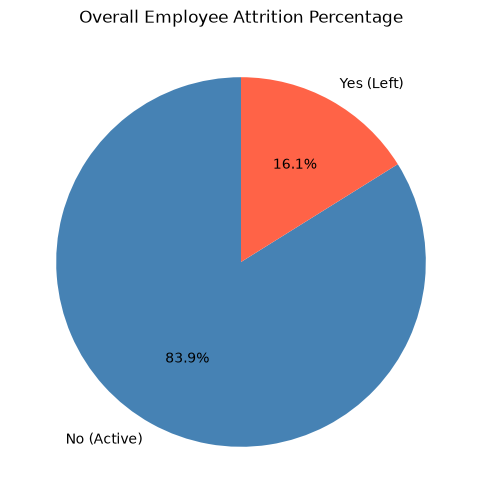

In [10]:

# Attrition count nikalna (0 aur 1 kitne hain)
attrition_counts = df['Attrition'].value_counts()

# Pie chart banana
plt.figure(figsize=(6, 6))
plt.pie(attrition_counts, labels=['No (Active)', 'Yes (Left)'], 
        autopct='%1.1f%%', colors=['#4682B4', '#FF6347'], startangle=90)

plt.title('Overall Employee Attrition Percentage')
plt.show()

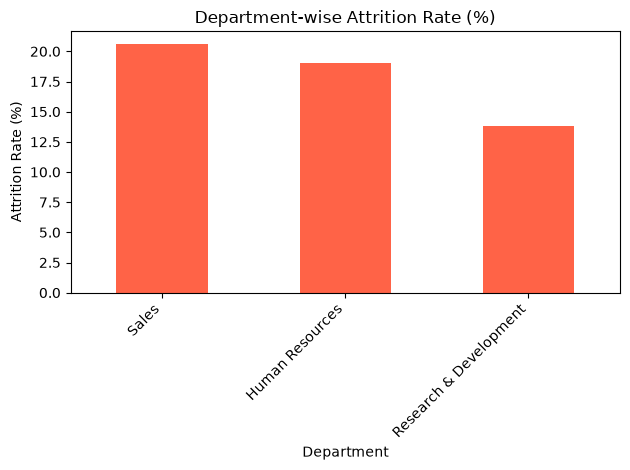

In [11]:
# Department-wise Attrition Rate calculate karke descending order mein sort karna
dept_attrition = df.groupby('Department')['Attrition'].mean().sort_values(ascending=False) * 100

# Bar chart banana (Sorted order mein)
dept_attrition.plot(kind='bar', color='#FF6347')

plt.title('Department-wise Attrition Rate (%)')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Chart ko save karna
plt.savefig('department_attrition_bar_chart.png')

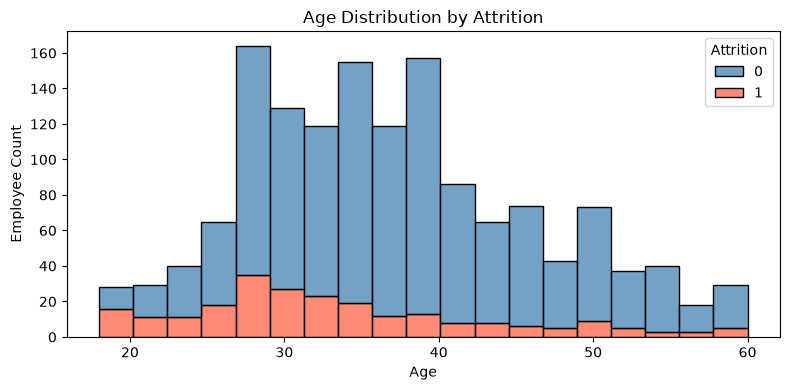

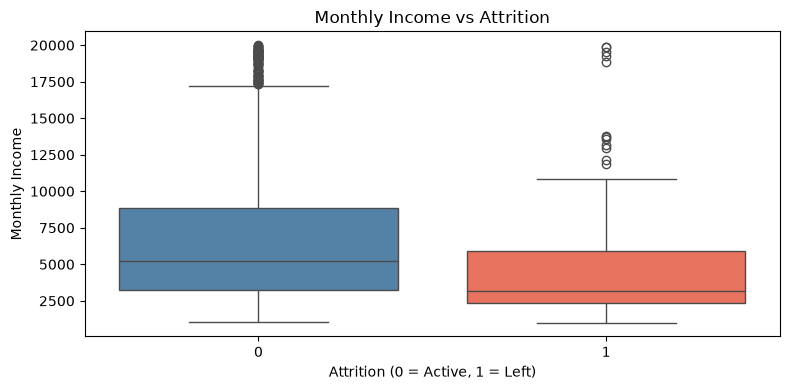

In [12]:
# 1. Age Distribution Histogram (Kish umar ke log sabse zyada job chhod rahe hain)
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Age', hue='Attrition', multiple='stack', palette=['#4682B4', '#FF6347'])
plt.title('Age Distribution by Attrition')
plt.xlabel('Age')
plt.ylabel('Employee Count')
plt.tight_layout()
plt.savefig('age_distribution_histogram.png')
plt.show()

# 2. Monthly Income Box Plot (Salary aur Attrition ka relation)
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette=['#4682B4', '#FF6347'])
plt.title('Monthly Income vs Attrition')
plt.xlabel('Attrition (0 = Active, 1 = Left)')
plt.ylabel('Monthly Income')
plt.tight_layout()
plt.savefig('income_vs_attrition_boxplot.png')
plt.show()

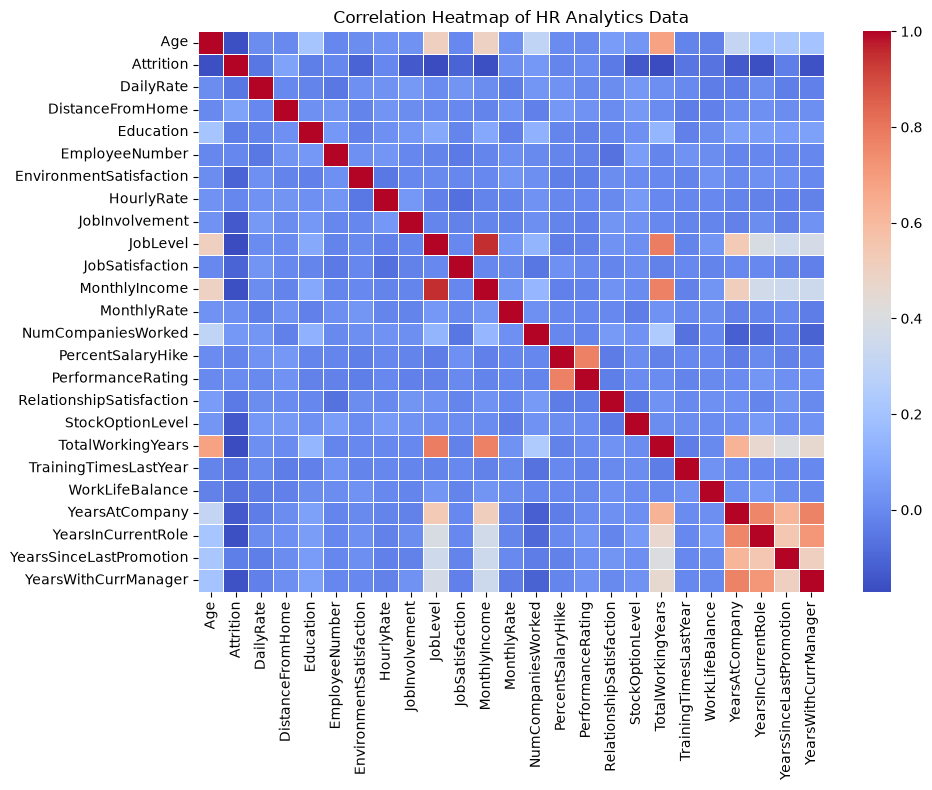

Success! Cleaned data successfully saved inside the 'Cleaned_Data' folder. Ready for Power BI!


In [15]:
import seaborn as sns

# 1. Correlation Heatmap banana
plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of HR Analytics Data')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

# 2. Cleaned Data ko exact 'Cleaned_Data' folder ke andar save karna
file_path_out = r'C:\Users\hp\Desktop\HR_Analytics_Portfolio_Project\1_Data\Cleaned_Data\cleaned_data.csv'
df.to_csv(file_path_out, index=False)

print("Success! Cleaned data successfully saved inside the 'Cleaned_Data' folder. Ready for Power BI!")